In [1]:
# !pip install ctgan
# !pip install scipy
# !pip install sklearn

   ---------------------------------------- 65.2/65.2 kB 3.4 MB/s eta 0:00:00
   ---------------------------------------- 1.8/1.8 MB 23.0 MB/s eta 0:00:00



[notice] A new release of pip is available: 24.0 -> 24.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from ctgan import CTGAN
from ctgan import load_demo

real_data = load_demo()

# Names of the columns that are discrete
discrete_columns = [
    'workclass',
    'education',
    'marital-status',
    'occupation',
    'relationship',
    'race',
    'sex',
    'native-country',
    'income'
]

ctgan = CTGAN(epochs=10)
ctgan.fit(real_data, discrete_columns)

# Create synthetic data
synthetic_data = ctgan.sample(1000)


# # CTGAN 모델 초기화 및 학습
# ctgan = CTGANSynthesizer(epochs=5)  # epochs는 테스트 목적으로 낮게 설정; 실제는 100-300을 고려해야 함
# ctgan.fit(df, ['income'])  # 'income'은 범주형 변수로 지정

# # 합성 데이터 생성
# synthetic_data = ctgan.sample(10)  # 실제 데이터와 동일한 수의 샘플 생성
# print(synthetic_data)

In [4]:
real_data

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [3]:
synthetic_data

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,52,Private,327073,HS-grad,9,Never-married,Sales,Own-child,White,Female,22,3,48,United-States,<=50K
1,34,Private,287981,Bachelors,9,Divorced,Tech-support,Not-in-family,Other,Male,7212,6,18,United-States,<=50K
2,26,Private,182585,11th,10,Never-married,Other-service,Wife,White,Female,132,6,15,?,<=50K
3,37,Self-emp-inc,679835,HS-grad,0,Married-civ-spouse,Other-service,Husband,White,Male,5071,-2,40,United-States,>50K
4,36,Private,34368,HS-grad,9,Never-married,Sales,Not-in-family,Asian-Pac-Islander,Female,48,6,48,Columbia,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,61,Private,316610,Some-college,12,Never-married,Other-service,Husband,White,Female,96,4,33,United-States,<=50K
996,18,Private,257979,Assoc-voc,13,Never-married,Adm-clerical,Unmarried,White,Female,68,7,40,United-States,<=50K
997,71,Private,261353,Some-college,3,Never-married,Adm-clerical,Not-in-family,White,Female,-2,6,40,Mexico,<=50K
998,32,State-gov,292578,HS-grad,10,Never-married,Protective-serv,Unmarried,White,Female,131,5,35,?,>50K


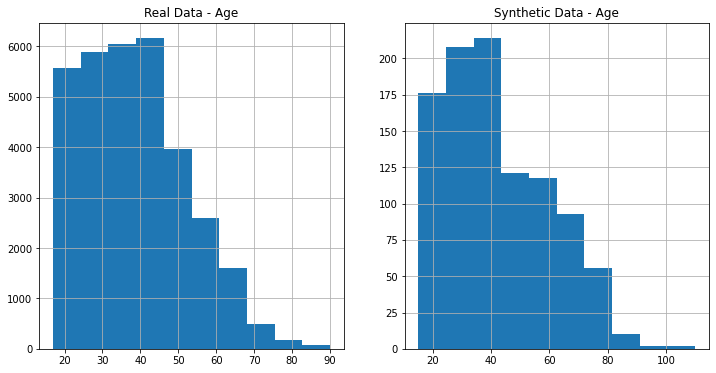

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# 실제 데이터와 합성 데이터의 'age' 컬럼 비교
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
real_data['age'].hist(ax=ax[0], bins=10)
ax[0].set_title('Real Data - Age')

synthetic_data['age'].hist(ax=ax[1], bins=10)
ax[1].set_title('Synthetic Data - Age')

plt.show()

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from scipy.stats import ks_2samp

# Kolmogorov-Smirnov Test (KS Test)
# KS Test를 사용하여 두 데이터 샘플(실제 데이터와 합성 데이터)의 분포가 유의미하게 다른지 검정합니다.
# 'age' 컬럼에 대한 KS test
ks_statistic, p_value = ks_2samp(real_data['age'], synthetic_data['age'])
print(f"KS Statistic: {ks_statistic}, P-value: {p_value}")

KS Statistic: 0.1196555081232149, P-value: 1.470454018054719e-12


제공된 콜모고로프-스미르노프 검정(KS Test)의 결과를 해석해 보겠습니다. 이 검정은 두 데이터 샘플의 누적 분포 함수(CDF)가 동일한지를 통계적으로 평가하는 방법입니다. 주로 두 데이터 집합이 같은 분포에서 나왔는지를 검정하는 데 사용됩니다.

##### KS Statistic: 0.1196555081232149
- KS 통계량: 이 값은 두 데이터 샘플의 CDF 사이의 최대 차이를 나타냅니다. 이 경우 값은 약 0.1197입니다. 이는 두 샘플의 CDF 사이에 최대 11.97%의 차이가 있다는 것을 의미합니다. KS 통계량이 큰 값이면 두 분포 사이의 차이가 크다는 것을 의미합니다.
  
##### P-value: 1.470454018054719e-12
- P-value: 이 값은 두 데이터 샘플의 분포가 같다는 귀무 가설 하에서 관찰된 통계량이나 더 극단적인 통계량이 관찰될 확률입니다. 이 경우 P-value는 약 
1.47×10(−12 승) 로 매우 작습니다. 일반적으로 P-value가 0.05(5%) 이하면 통계적으로 유의미하다고 판단하여 귀무 가설을 기각합니다.        

#### 해석
- 결과: 이 경우, P-value가 매우 낮기 때문에, 우리는 귀무 가설인 "두 데이터 샘플이 같은 분포에서 유래했다"를 기각할 수 있습니다. 즉, 통계적으로 유의미한 차이가 있으며, 두 데이터 샘플은 다른 분포를 가지고 있다고 볼 수 있습니다.
#### 결론 
이 결과는 합성 데이터와 실제 데이터가 같은 분포에서 나오지 않았다는 것을 의미합니다. 합성 데이터가 실제 데이터의 통계적 특성을 완벽하게 모방하지 못했다고 해석할 수 있으며, 합성 과정에서의 개선이 필요할 수 있습니다. 이러한 정보는 합성 데이터 생성 모델을 조정하거나 다른 모델링 기법을 시도할 때 중요한 피드백이 될 수 있습니다.

콜모고로프-스미르노프 검정(Kolmogorov-Smirnov Test, KS Test)에서 KS 통계량은 두 누적 분포 함수(CDF) 사이의 최대 차이를 나타내는 값입니다. 두 데이터 샘플이 완전히 동일한 분포를 가지고 있다면, 이론적으로 이 최대 차이, 즉 KS 통계량은 0이 됩니다. 다시 말해, 두 분포가 완전히 같으면 그 차이는 없다고 볼 수 있으므로, KS 통계량은 0에 가까워집니다.

KS 통계량의 일반적인 기대치
통계량이 0에 가까울 경우: 두 샘플 간에는 분포 차이가 거의 또는 전혀 없다는 것을 의미합니다.
통계량이 0보다 크고 증가할 경우: 두 샘플의 분포가 점점 더 다르다는 것을 나타내며, 차이가 클수록 두 분포의 유사성이 낮다는 것을 의미합니다.
실제 상황에서의 KS 통계량 해석          
KS 통계량 값이 매우 작은 경우 (예: 0.05 이하): 두 분포가 통계적으로 유사하다고 간주할 수 있습니다. 그러나 이 경우에도 P-value를 함께 고려하여 통계적 유의성을 평가해야 합니다.           
KS 통계량 값이 상대적으로 큰 경우 (예: 0.2 이상): 이는 두 분포 사이에 중요한 차이가 있음을 시사하며, 통계적으로 유의미할 가능성이 높습니다.
결론               
KS 통계량은 두 데이터 집합의 분포 차이를 수치화하는 데 유용하지만, 이 수치만으로는 완전한 결론을 내리기 어렵습니다. 분석가는 KS 통계량과 함께 P-value와 실제 데이터의 맥락을 고려하여 두 데이터 집합의 분포 차이를 종합적으로 평가해야 합니다. 이렇게 함으로써 데이터의 분포 차이에 대한 보다 정확하고 실제적인 이해를 얻을 수 있습니다.

In [8]:
# 머신 러닝 모델을 이용한 분류기 성능 비교
# 합성 데이터와 실제 데이터를 학습 데이터셋과 테스트 데이터셋으로 나누어 머신 러닝 모델의 성능을 비교합니다.

# 데이터 라벨링 (실제 데이터는 0, 합성 데이터는 1)
real_data['label'] = 0
synthetic_data['label'] = 1

# 데이터 병합 및 훈련 데이터 / 테스트 데이터 분리
combined_data = pd.concat([real_data, synthetic_data])
X = combined_data[['age']]
y = combined_data['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 랜덤 포레스트 분류기 학습
classifier = RandomForestClassifier()
classifier.fit(X_train, y_train)

# 성능 평가
predictions = classifier.predict(X_test)
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      9797
           1       1.00      0.08      0.16       272

    accuracy                           0.98     10069
   macro avg       0.99      0.54      0.57     10069
weighted avg       0.98      0.98      0.96     10069



1. 기술 통계 비교
합성 데이터와 실제 데이터의 기술 통계(평균, 중앙값, 분산, 최대값, 최소값 등)를 비교합니다. 이를 통해 데이터 분포의 일치 여부를 확인할 수 있습니다.

2. 분포 검사
히스토그램 비교: 각 변수의 히스토그램을 그려 두 데이터 세트의 분포를 시각적으로 비교합니다.
밀도 플롯: 연속 변수의 경우, 커널 밀도 추정을 사용하여 밀도 플롯을 그리고 두 데이터 세트의 유사성을 평가합니다.
3. 상관 관계 분석
두 데이터 세트 간의 변수들의 상관 계수를 계산하여 비교합니다. 합성 데이터가 실제 데이터의 변수 간 상호작용을 잘 모사하는지 평가할 수 있습니다.

4. 고급 통계적 테스트
콜모고로프-스미르노프 테스트(KS Test): 두 샘플의 누적 분포 함수(CDF)가 동일한지 통계적으로 검정합니다. 이는 두 데이터 세트의 분포가 유사한지 판단하는 데 사용됩니다.
카이제곱 검정: 범주형 데이터의 경우, 카이제곱 검정을 사용하여 합성 데이터가 실제 데이터의 범주 분포를 잘 따르는지 검정할 수 있습니다.
5. 머신 러닝 모델 기반 평가
모델 성능 비교: 동일한 머신 러닝 알고리즘을 사용하여 합성 데이터와 실제 데이터 각각에서 모델을 훈련시킨 후, 두 모델의 성능(정확도, F1 점수, ROC AUC 등)을 비교합니다.
교차 검증: 합성 데이터로 훈련된 모델을 실제 데이터로 테스트하거나 그 반대로 실행하여 두 데이터 세트 간의 일치도를 평가합니다.
6. 도메인 전문가의 검토
특정 분야의 전문가에게 합성 데이터를 검토받아 실제 데이터와의 유사성 및 타당성을 평가받습니다. 이는 특히 의료, 금융 등 전문 지식이 필요한 분야에서 중요합니다.

이러한 방법들을 통해 합성 데이터의 품질을 평가하고, 실제 데이터를 대체하거나 보완할 때 발생할 수 있는 문제를 사전에 파악하고 해결할 수 있습니다. 각 평가 방법은 데이터의 특성과 사용 목적에 따라 적절히 선택되어야 합니다.

In [5]:
!pip install sdv

   ---------------------------------------- 146.4/146.4 kB 4.4 MB/s eta 0:00:00
   ---------------------------------------- 139.2/139.2 kB 8.6 MB/s eta 0:00:00
   ---------------------------------------- 12.4/12.4 MB 27.3 MB/s eta 0:00:00
   ---------------------------------------- 51.9/51.9 kB 2.6 MB/s eta 0:00:00
   ---------------------------------------- 170.5/170.5 kB 5.2 MB/s eta 0:00:00
   ---------------------------------------- 17.3/17.3 MB 20.4 MB/s eta 0:00:00
   ---------------------------------------- 82.7/82.7 kB 4.8 MB/s eta 0:00:00



[notice] A new release of pip is available: 24.0 -> 24.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
import sdv

print(sdv.version.public)

1.15.0


In [10]:
from sdv.datasets.demo import download_demo
from sdv.single_table import GaussianCopulaSynthesizer

real_data, metadata = download_demo(
  'single_table', 'fake_hotel_guests')

synthesizer = GaussianCopulaSynthesizer(metadata)
synthesizer.fit(real_data)

synthetic_data = synthesizer.sample(num_rows=10)

In [ ]:
from sdv.datasets.local import load_csvs
from sdv.datasets.demo import download_demo

# This is the default folder name that the GOogle Colab notebook uses.
# Change this if you have your own folder with CSV files.
FOLDER_NAME = 'content/'

try:
  data = load_csvs(folder_name='/content/')
except ValueError:
  print('You have not uploaded any csv files. Using some demo data instead.')
  data, _ = download_demo(
    modality='multi_table',
    dataset_name='fake_hotels'
  )

data.keys()